# 第七階段:整合成一張 play 卡(單頁摘要)

**最終目標**:做一個「傳球空間分析」工具,給教練或球探使用。

**本階段只做一件事**:把前面做好的三個指標 —— separation(第三階段)、Voronoi 控制區(第五階段)、passing lane(第六階段)—— 整合進**同一張圖**,做成一個「輸入一個 play、輸出一張單頁摘要」的 play 卡。

這是把散落在各筆記本的分析,收斂成**教練看得懂、拿得出手**的產物 —— 往「分析工具」的產品形態邁進的第一步。

---

### play 卡的版面(2 × 2)

| 左上:場上快照(snap) | 右上:Voronoi 控制區 |
|---|---|
| **左下:separation 隨時間** | **右下:傳球路徑圖** |

加上最上方的總標題,帶出這個 play 的基本資訊(對戰、檔數、結果、文字描述)。

> 這一階段**不發明新指標**,全部沿用前面驗證過的計算,只是重新組裝與排版。

## 步驟 0:載入工具與設定路徑

- **輸入**:無
- **輸出**:工具與路徑
- **目的**:準備工具。整合所有前面階段用到的套件。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.spatial import cKDTree

plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

sys.path.append(str(Path.cwd().parent))
from config import DATA_DIR, SAMPLE_GAME_ID

print("gameId:", SAMPLE_GAME_ID)

gameId: 2021090900


## 步驟 1:載入整場資料(一次)

- **輸入**:`plays`、`players`、`pff`、整場 `tracking`
- **輸出**:四個 DataFrame
- **目的**:play 卡函式會反覆用到這些,先讀一次放記憶體。

In [2]:
plays = pd.read_csv(DATA_DIR / "plays.csv")
players = pd.read_csv(DATA_DIR / "players.csv")
pff = pd.read_csv(DATA_DIR / "pffScoutingData.csv")
tracking = pd.read_csv(DATA_DIR / "tracking" / f"tracking_{SAMPLE_GAME_ID}.csv")

id2name = players.set_index("nflId")["displayName"].to_dict()

# 球場網格(Voronoi 用),先建好重複使用
FIELD_X, FIELD_Y, STEP = 120.0, 53.3, 0.5
_gx = np.arange(0, FIELD_X, STEP) + STEP / 2
_gy = np.arange(0, FIELD_Y, STEP) + STEP / 2
_GX, _GY = np.meshgrid(_gx, _gy)
GRID = np.column_stack([_GX.ravel(), _GY.ravel()])
CELL_AREA = STEP * STEP

print("資料載入完成。tracking:", tracking.shape, "/ 網格點:", len(GRID))

資料載入完成。tracking: (92644, 16) / 網格點: 25680


## 步驟 2:把一個 play 的所有資料整理成一包

- **輸入**:一個 `playId`
- **輸出**:`dict`,含片段、角色分組、關鍵 frame、球隊、play 資訊
- **目的**:play 卡的四張子圖都需要同一批資料。先用一個函式把它們一次備齊,避免每張圖重算。

> 這一步整合了第二階段(切片段 + 接角色)、第三/五/六階段的共同前置。若不是傳球 play 就回傳 None。

In [3]:
def prepare_play(play_id):
    """備齊一個 play 畫 play 卡需要的所有資料。非傳球 play 回傳 None。"""
    pl = plays[(plays["gameId"] == SAMPLE_GAME_ID) & (plays["playId"] == play_id)]
    if pl.empty:
        return None
    pl = pl.iloc[0]

    pt = tracking[(tracking["gameId"] == SAMPLE_GAME_ID) & (tracking["playId"] == play_id)]
    snap_rows = pt.loc[pt["event"] == "ball_snap", "frameId"]
    pass_rows = pt.loc[pt["event"] == "pass_forward", "frameId"]
    if snap_rows.empty or pass_rows.empty:
        return None
    snap_frame, pass_frame = snap_rows.iloc[0], pass_rows.iloc[0]

    roles = pff[(pff["gameId"] == SAMPLE_GAME_ID) & (pff["playId"] == play_id)][["nflId", "pff_role"]]

    seg = (
        pt[(pt["frameId"] >= snap_frame) & (pt["frameId"] <= pass_frame)]
        .merge(players[["nflId", "displayName"]], on="nflId", how="left")
        .merge(roles, on="nflId", how="left")
    )
    return {
        "play_id": play_id,
        "info": pl,
        "off_team": pl["possessionTeam"],
        "def_team": pl["defensiveTeam"],
        "snap_frame": snap_frame,
        "pass_frame": pass_frame,
        "seg": seg,
    }


d = prepare_play(137)
print("playId=137 備齊:", None if d is None else f"片段 {d['seg']['frameId'].nunique()} frame, {d['off_team']} vs {d['def_team']}")

playId=137 備齊: 片段 26 frame, DAL vs TB


## 步驟 3:四張子圖各包一個函式

- **輸入**:上一步的資料包 `d`、一個 matplotlib 的 `ax`
- **輸出**:在指定的 `ax` 上畫好一張子圖
- **目的**:把四個分析各做成「畫到指定格子」的函式,之後 play 卡只要依序呼叫、擺進 2×2 版面。

每個函式對應前面一個階段的計算,邏輯完全沿用,只是改成畫到傳入的 `ax`。

In [4]:
def _point_to_segment(px, py, ax0, ay0, bx, by):
    vx, vy = bx - ax0, by - ay0
    wx, wy = px - ax0, py - ay0
    L2 = vx * vx + vy * vy
    if L2 == 0:
        return np.hypot(px - ax0, py - ay0), 0.0
    t = (wx * vx + wy * vy) / L2
    tc = max(0.0, min(1.0, t))
    cx, cy = ax0 + tc * vx, ay0 + tc * vy
    return np.hypot(px - cx, py - cy), t


def panel_snapshot(d, ax):
    """左上:snap 當下場上快照(第二階段)"""
    snap = d["seg"][(d["seg"]["frameId"] == d["snap_frame"]) & d["seg"]["nflId"].notna()]
    off = snap[snap["team"] == d["off_team"]]
    deff = snap[snap["team"] == d["def_team"]]
    ax.scatter(off["x"], off["y"], c="tab:blue", s=60, label=f"進攻 {d['off_team']}")
    ax.scatter(deff["x"], deff["y"], c="tab:red", s=60, label=f"防守 {d['def_team']}")
    ax.set_xlim(0, FIELD_X); ax.set_ylim(0, FIELD_Y); ax.set_aspect("equal")
    ax.set_title("① 發球當下場上位置"); ax.legend(loc="upper right", fontsize=7)


def panel_voronoi(d, ax):
    """右上:snap 當下 Voronoi 控制區(第五階段)"""
    snap = d["seg"][(d["seg"]["frameId"] == d["snap_frame"]) & d["seg"]["nflId"].notna()]
    pts = snap[["x", "y"]].to_numpy(); teams = snap["team"].to_numpy()
    _, idx = cKDTree(pts).query(GRID)
    owner = teams[idx]
    off_pct = (owner == d["off_team"]).sum() / len(owner) * 100
    owner_grid = (owner == d["def_team"]).astype(int).reshape(_GX.shape)
    ax.imshow(owner_grid, origin="lower", extent=[0, FIELD_X, 0, FIELD_Y],
              cmap=ListedColormap(["#a6c8ff", "#ffb3b3"]), alpha=0.7, aspect="equal")
    ax.scatter(snap[snap["team"] == d["off_team"]]["x"], snap[snap["team"] == d["off_team"]]["y"],
               c="tab:blue", s=40)
    ax.scatter(snap[snap["team"] == d["def_team"]]["x"], snap[snap["team"] == d["def_team"]]["y"],
               c="tab:red", s=40)
    ax.set_xlim(0, FIELD_X); ax.set_ylim(0, FIELD_Y)
    ax.set_title(f"② Voronoi 控制區(進攻控制 {off_pct:.0f}%)")


def panel_separation(d, ax):
    """左下:separation 隨時間(第三階段)"""
    rec = d["seg"][d["seg"]["pff_role"] == "Pass Route"]
    dfn = d["seg"][d["seg"]["pff_role"] == "Coverage"]
    for name, rg in rec.groupby("displayName"):
        xs, ys = [], []
        for fid, rrow in rg.groupby("frameId"):
            dd = dfn[dfn["frameId"] == fid][["x", "y"]].to_numpy()
            r0 = rrow.iloc[0]
            mind = np.sqrt((dd[:, 0] - r0["x"]) ** 2 + (dd[:, 1] - r0["y"]) ** 2).min()
            xs.append((fid - d["snap_frame"]) * 0.1); ys.append(mind)
        ax.plot(xs, ys, marker="o", markersize=2, label=name)
    pass_sec = (d["pass_frame"] - d["snap_frame"]) * 0.1
    ax.axvline(pass_sec, color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("發球後秒數"); ax.set_ylabel("separation(碼)")
    ax.set_title("③ 接球員與最近防守者距離"); ax.legend(fontsize=6, loc="upper left")
    ax.grid(True, alpha=0.3)


def panel_lanes(d, ax):
    """右下:傳球路徑圖(第六階段)"""
    fr = d["seg"][(d["seg"]["frameId"] == d["pass_frame"]) & d["seg"]["nflId"].notna()]
    qb = fr[fr["pff_role"] == "Pass"].iloc[0]
    rec = fr[fr["pff_role"] == "Pass Route"]
    dfn = fr[fr["pff_role"] == "Coverage"]
    for _, r in rec.iterrows():
        blockers = [dist for _, dd in dfn.iterrows()
                    for dist, t in [_point_to_segment(dd["x"], dd["y"], qb["x"], qb["y"], r["x"], r["y"])]
                    if 0 <= t <= 1]
        md = min(blockers) if blockers else np.nan
        color = "tab:green" if (np.isnan(md) or md >= 3) else ("orange" if md >= 1.5 else "tab:red")
        ax.plot([qb["x"], r["x"]], [qb["y"], r["y"]], "--", color=color, linewidth=1.3)
    ax.scatter(rec["x"], rec["y"], c="tab:blue", s=50, label="接球員")
    ax.scatter(dfn["x"], dfn["y"], c="tab:red", s=50, label="防守員")
    ax.scatter([qb["x"]], [qb["y"]], c="black", s=110, marker="*", label="QB")
    ax.set_xlim(0, FIELD_X); ax.set_ylim(0, FIELD_Y); ax.set_aspect("equal")
    ax.set_title("④ 傳球路徑(綠乾淨/橘靠近/紅被擋)"); ax.legend(fontsize=7, loc="upper right")


print("四個子圖函式已定義。")

四個子圖函式已定義。


## 步驟 4:組裝 play 卡

- **輸入**:一個 `playId`
- **輸出**:一張 2×2 的 play 卡(matplotlib figure)
- **目的**:把四張子圖擺進一張圖,加上帶 play 資訊的總標題。這就是最終給教練看的單頁摘要。

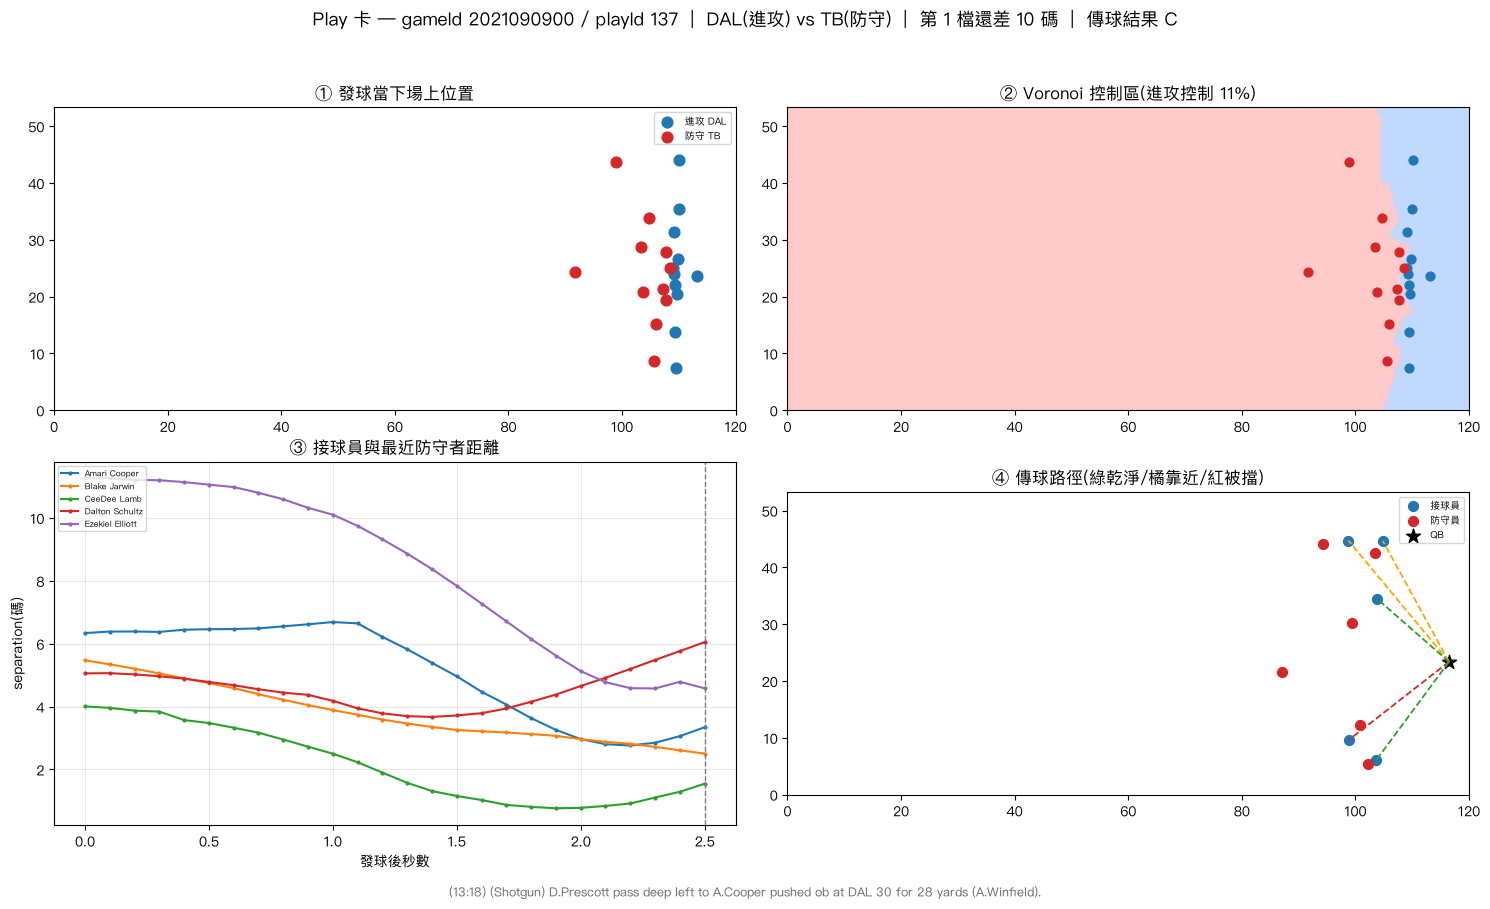

In [5]:
def play_card(play_id):
    d = prepare_play(play_id)
    if d is None:
        print(f"playId={play_id} 不是(完整的)傳球 play,無法製卡。")
        return None
    info = d["info"]

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    panel_snapshot(d, axes[0, 0])
    panel_voronoi(d, axes[0, 1])
    panel_separation(d, axes[1, 0])
    panel_lanes(d, axes[1, 1])

    # 總標題:play 基本資訊
    down = info.get("down", "?"); ytg = info.get("yardsToGo", "?")
    res = info.get("passResult", "?")
    title = (f"Play 卡 — gameId {SAMPLE_GAME_ID} / playId {play_id}  |  "
             f"{d['off_team']}(進攻) vs {d['def_team']}(防守)  |  "
             f"第 {down} 檔還差 {ytg} 碼  |  傳球結果 {res}")
    fig.suptitle(title, fontsize=13, y=0.99)
    # play 文字描述放在最下方
    fig.text(0.5, 0.005, info.get("playDescription", ""), ha="center", fontsize=9, color="dimgray")
    fig.tight_layout(rect=[0, 0.02, 1, 0.97])
    return fig


fig = play_card(137)
plt.show()

## 步驟 5:換一個 play 試試(驗證可重用)

- **輸入**:另一個傳球 `playId`
- **輸出**:另一張 play 卡
- **目的**:play 卡的價值在於**換個 play 就能用**。這裡挑同場另一個傳球 play,確認函式一般化、沒有寫死在 137。

換一個 play 試:playId = 97


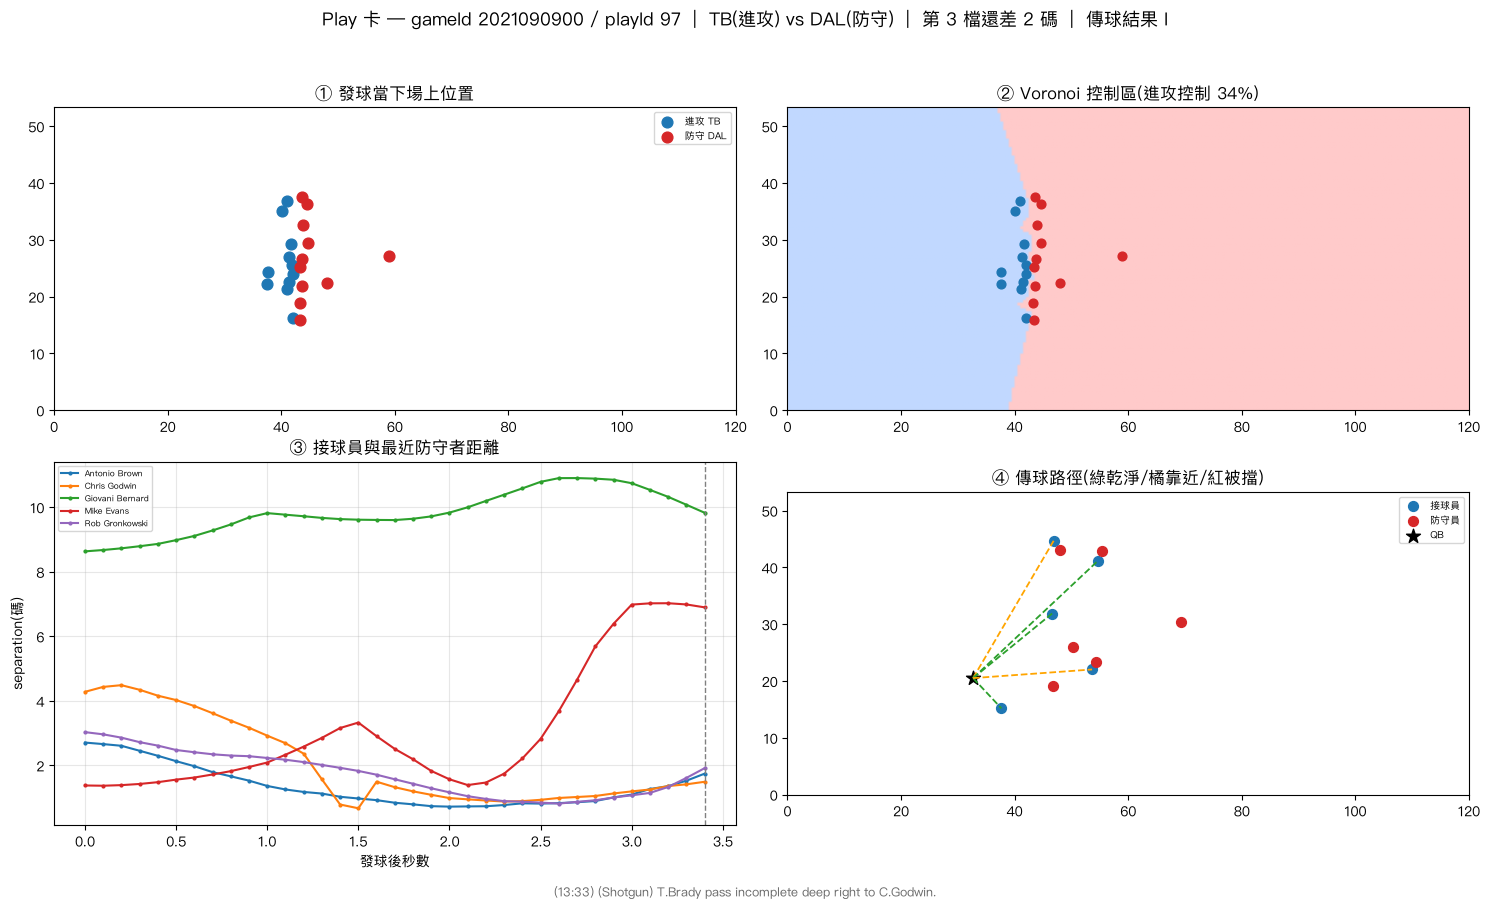

In [6]:
# 找同場另一個傳球 play(有 snap 且有 pass_forward),挑第一個不是 137 的
candidates = []
for pid in sorted(tracking["playId"].unique()):
    if pid == 137:
        continue
    pt = tracking[tracking["playId"] == pid]
    if (pt["event"] == "ball_snap").any() and (pt["event"] == "pass_forward").any():
        candidates.append(pid)

other = candidates[0]
print("換一個 play 試:playId =", other)
fig2 = play_card(other)
plt.show()

## 本階段完成了什麼

- 把前面三個指標(separation、Voronoi 控制區、passing lane)+ 場上快照,整合進**同一張 2×2 play 卡**。
- 做成 `play_card(play_id)` 函式:**輸入一個 play、輸出一張單頁摘要**,換個 play 就能重用。
- 加上帶 play 資訊的總標題與文字描述,讓不看程式的人也能讀懂這個 play。
- 用另一個 play 驗證函式一般化,沒有寫死在示範的那個 play。

**這一步的意義**:專案第一次有了「拿得出手給教練看」的產物 —— 從一堆分析筆記本,收斂成一個工具的雛形。

**下一階段(等你確認理解後再開始)**:
1. **把 play 卡存成圖檔 / PDF**:批次對整場傳球 play 產出卡片,變成可翻閱的賽後報告。
2. **用球的飛行軌跡修正 passing lane**:讓第④格對深傳更準(第六階段留下的已知侷限)。
3. **做成互動介面**:用下拉選單選 play、即時出卡,往真正的『工具』邁進。